# Unsupervised NN

### Model Character
input:
- distribution of d_k (sum = 1)
- |H_k|

output:
- list of b_k
- list of f_dt_k
- list of beta_k

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch


if torch.backends.mps.is_available():
    device = 'mps'
    print("Success: Using Apple Silicon GPU acceleration.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("Success: Using Cuda GPU acceleration.")
else:
    device = 'cpu'
    print("Using CPU.")

Success: Using Cuda GPU acceleration.


Read Data

In [3]:
from SymetricOptim import SymmetricResidualNet


K = 4
B_total = 100e3
C_DT_total = 50e6
beta_max = 3
model = SymmetricResidualNet(4, B_total, C_DT_total, beta_max)

In [4]:
from DataUtil import generate_data_loader


data_loader = generate_data_loader(int(1e5), K, 16e3, 64)

In [5]:
from TrainingUtil import unsupervised_loss, train
from torch.optim import Adam, lr_scheduler
from EarlyStopping import EarlyStopping


optimizer = Adam(model.parameters(), lr=0.01)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopper = EarlyStopping(patience=7, min_delta=0.01)
loss_fn = unsupervised_loss

train(model, data_loader, optimizer, scheduler, early_stopper, loss_fn, device, n_epoch=100)

start training
epoch: 01, avg loss: 44.63174980417399
epoch: 02, avg loss: 42.95268906772098
epoch: 03, avg loss: 41.601656183400216
epoch: 04, avg loss: 39.371036949328555
epoch: 05, avg loss: 39.04456896913105
epoch: 06, avg loss: 39.69449838551663
epoch: 07, avg loss: 38.90578152198328
epoch: 08, avg loss: 38.83229193928451
epoch: 09, avg loss: 39.20058566122122
epoch: 10, avg loss: 39.032848172666775
epoch: 11, avg loss: 38.598738907699925
epoch: 12, avg loss: 38.60121614476922
epoch: 13, avg loss: 38.53486807927518
epoch: 14, avg loss: 38.55553882791686
epoch: 15, avg loss: 38.629087999701426
epoch: 16, avg loss: 38.45946658275407
epoch: 17, avg loss: 38.50857477682337
epoch: 18, avg loss: 38.417461527057434
epoch: 19, avg loss: 38.40081856179069
epoch: 20, avg loss: 38.38203290938111
epoch: 21, avg loss: 38.991683336381186
epoch: 22, avg loss: 38.57804973111729
epoch: 23, avg loss: 38.633191931804475
epoch: 24, avg loss: 38.51814288812346
epoch: 25, avg loss: 38.3685572704137
epo

In [6]:
# state_dict = torch.load('model/checkpoint.pth', map_location=device, weights_only=True)
# model.to(device)
# model.load_state_dict(state_dict)

|   sensor_num |          b |             f |   beta |    time |
|-------------:|-----------:|--------------:|-------:|--------:|
|       0.0000 | 25018.4258 | 12635192.0000 | 1.3775 | 19.4832 |
|       1.0000 | 24983.0215 | 12419296.0000 | 1.3699 | 18.0024 |
|       2.0000 | 25011.5820 | 12543411.0000 | 1.3736 | 18.1629 |
|       3.0000 | 24986.9766 | 12402105.0000 | 1.3693 | 17.7852 |

None
[3.3417192 3.390003  3.3655803 3.3876352]


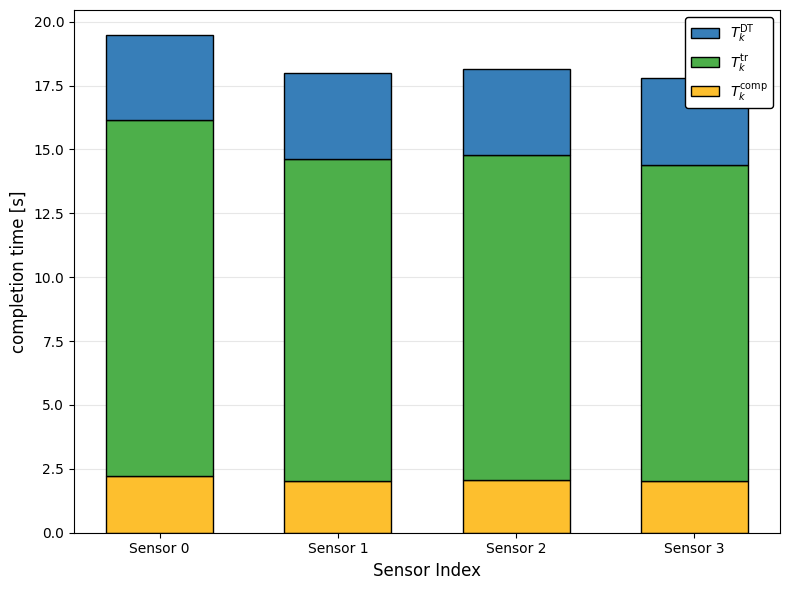

In [48]:
import TrainingUtil as tu
import DataUtil as du
import Plotting as pt
import ProcessTime as process

length=1000

H_k = du.generate_channel_gains(length, 4)


D_k = torch.tensor([[1, 1, 1, 1]]).repeat(length, 1) * 4e3
X_test = torch.cat((D_k, H_k), dim=1).to(device)
with torch.no_grad():
    model.eval()
    b, f, beta = model(X_test)
    pt.plot_result(process.t_comp(X_test, b, f, beta, numpy=True).mean(0), process.t_tr(X_test, b, f, beta, numpy=True).mean(0), process.t_dt(X_test, b, f, beta, numpy=True).mean(0))
    print(tu.print_avg(X_test, b, f, beta))
    print(process.t_dt(X_test, b, f, beta, numpy=True).mean(0))